<a href="https://colab.research.google.com/github/fquinterov/computer_vision_course/blob/main/ml_image_processing_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Course
## Deep learning for images tutorial

This notebook is a tutorial to implement some trained models to classify and perform detections of images. We use the Hugging Face API to deploy the models.

## Setup


First, let's copy some files into this Google Colab Notebook.

In [1]:
!git clone https://github.com/ml4design/image-processing-tutorial

Cloning into 'image-processing-tutorial'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 120 (delta 14), reused 12 (delta 10), pack-reused 100 (from 1)
Receiving objects: 100% (120/120), 61.52 MiB | 20.06 MiB/s, done.
Resolving deltas: 100% (23/23), done.


Often you need to import packages to do fancy works.
In this tutorial, the tool (Google Colab) takes care of the package installation for you.

In [2]:
"""
# Import python packages.
"""
import json
import requests
import cv2
from google.colab import userdata
from IPython.display import Image

Specify the API URL and token of the Hugging Face API.

In this tutorial, we are going to use the Hugging Face API.  
API means the Application Programming Interface, which allows computer programs to talk to each other.  
`API_URL` is the Hugging Face API URL that points to a model that we want to use.  
For more information about the model, see the following page:  
- https://huggingface.co/google/vit-base-patch16-224

`API_TOKEN` is the Hugging Face API token for authentication.  
Please do not make the API token public.  
For more information about how to use the API, see the following page:  
- https://api-inference.huggingface.co/docs/python/html/quicktour.html

In [5]:
# Below is a reusable function for interacting with the Hugging Face API.
import requests
API_TOKEN = userdata.get('API_TOKEN')

API_URL = "https://router.huggingface.co/hf-inference/models/google/vit-base-patch16-224"

def query(file_path, api_url, api_token):
    with open(file_path, "rb") as f:
        data = f.read()
    headers = {"Authorization": f"Bearer " + api_token}
    response = requests.post(api_url, headers={"Content-Type": "image/jpeg", **headers}, data=data)
    return response.json()

## Query
Use the Hugging Face API to ask a model to make predictions.

Now we use the above `query` function to ask the API to predict what is in this image.  
You can replace the `my_image` variable with your own images.  
Note that `my_image` is a path that points to a file.  
In this case, `"/content/image-processing-tutorial/data/000000039769.jpeg"` is a relative path.  
This means that `"000000039769.jpeg"` is placed in the "data" folder.  
And the `data` folder downloaded by the first code block in this Google Colab workspace.

In [6]:
import requests

API_URL = "https://router.huggingface.co/hf-inference/models/google/vit-base-patch16-224"
my_image = "/content/image-processing-tutorial/data/000000039769.jpeg"

data = query(my_image, API_URL, API_TOKEN)
data

[{'label': 'Egyptian cat', 'score': 0.9374415874481201},
 {'label': 'tabby, tabby cat', 'score': 0.038442619144916534},
 {'label': 'tiger cat', 'score': 0.01441141776740551},
 {'label': 'lynx, catamount', 'score': 0.003274322487413883},
 {'label': 'Siamese cat, Siamese', 'score': 0.0006795930676162243}]

The output looks like below:  
    `[{'label': 'Egyptian cat', 'score': 0.9374415874481201}, {'label': 'tabby, tabby cat', 'score': 0.03844254091382027}, {'label': 'tiger cat', 'score': 0.01441141776740551}, {'label': 'lynx, catamount', 'score': 0.003274336690083146}, {'label': 'Siamese cat, Siamese', 'score': 0.0006795947556383908}]`

The output is an array of five dictionaries that represent the top 5 predictions from the model.  
Array and dictionary are both data structures.
An array looks like [0, 1, 2, 3], which represents a list of elements (such as numbers).  
A dictionary looks like {"key1": "value1", "key2", "value2"}, which represents pairs of keys and values.  
In this case, the first element in the array {'score': 0.937, 'label': 'Egyptian cat'} is the first prediction.  
It means that the model thinks there are Egyptian cats in the image, with 0.937 probability (which is very high).

In [7]:
# use this line of code to print the output in a more organized and readable way.
print(json.dumps(data, indent=2))

[
  {
    "label": "Egyptian cat",
    "score": 0.9374415874481201
  },
  {
    "label": "tabby, tabby cat",
    "score": 0.038442619144916534
  },
  {
    "label": "tiger cat",
    "score": 0.01441141776740551
  },
  {
    "label": "lynx, catamount",
    "score": 0.003274322487413883
  },
  {
    "label": "Siamese cat, Siamese",
    "score": 0.0006795930676162243
  }
]


Lets try another image by chaning the `my_image` variable, running the query again, and printing the results.

In [8]:
my_image = "/content/image-processing-tutorial/data/bike/1/271758547_496887881809012_1375450742634622577_n.jpg"
data = query(my_image, API_URL, API_TOKEN)
print(data)
# print(json.dumps(data, indent=2))

[{'label': 'mountain bike, all-terrain bike, off-roader', 'score': 0.2128317803144455}, {'label': 'bicycle-built-for-two, tandem bicycle, tandem', 'score': 0.11649935692548752}, {'label': 'minibus', 'score': 0.044898614287376404}, {'label': 'tricycle, trike, velocipede', 'score': 0.026173599064350128}, {'label': 'moving van', 'score': 0.024126119911670685}]


Now, let's try another model by chaing the `API_URL` to a object detection model.

In [9]:
API_URL = "https://api-inference.huggingface.co/models/facebook/detr-resnet-50"
my_image = "/content/image-processing-tutorial/data/bike/1/271758547_496887881809012_1375450742634622577_n.jpg"
data = query(my_image, API_URL, API_TOKEN)
print(data)
# print(json.dumps(data, indent=2))

[{'score': 0.6458535194396973, 'label': 'bicycle', 'box': {'xmin': 72, 'ymin': 256, 'xmax': 274, 'ymax': 533}}, {'score': 0.7716385126113892, 'label': 'car', 'box': {'xmin': 291, 'ymin': 157, 'xmax': 377, 'ymax': 194}}, {'score': 0.9968470931053162, 'label': 'bicycle', 'box': {'xmin': 333, 'ymin': 216, 'xmax': 522, 'ymax': 531}}, {'score': 0.9547537565231323, 'label': 'bicycle', 'box': {'xmin': 695, 'ymin': 227, 'xmax': 813, 'ymax': 507}}, {'score': 0.6936920881271362, 'label': 'car', 'box': {'xmin': 10, 'ymin': 156, 'xmax': 57, 'ymax': 188}}, {'score': 0.9529551863670349, 'label': 'truck', 'box': {'xmin': 11, 'ymin': 154, 'xmax': 60, 'ymax': 187}}, {'score': 0.8967230319976807, 'label': 'car', 'box': {'xmin': 0, 'ymin': 170, 'xmax': 15, 'ymax': 193}}, {'score': 0.5774036645889282, 'label': 'car', 'box': {'xmin': 10, 'ymin': 171, 'xmax': 53, 'ymax': 201}}, {'score': 0.9960638880729675, 'label': 'person', 'box': {'xmin': 14, 'ymin': 171, 'xmax': 40, 'ymax': 227}}, {'score': 0.9935135245

In [8]:
print(json.dumps(data, indent=2))

[
  {
    "score": 0.6458535194396973,
    "label": "bicycle",
    "box": {
      "xmin": 72,
      "ymin": 256,
      "xmax": 274,
      "ymax": 533
    }
  },
  {
    "score": 0.7716385126113892,
    "label": "car",
    "box": {
      "xmin": 291,
      "ymin": 157,
      "xmax": 377,
      "ymax": 194
    }
  },
  {
    "score": 0.9968470931053162,
    "label": "bicycle",
    "box": {
      "xmin": 333,
      "ymin": 216,
      "xmax": 522,
      "ymax": 531
    }
  },
  {
    "score": 0.9547537565231323,
    "label": "bicycle",
    "box": {
      "xmin": 695,
      "ymin": 227,
      "xmax": 813,
      "ymax": 507
    }
  },
  {
    "score": 0.6936920881271362,
    "label": "car",
    "box": {
      "xmin": 10,
      "ymin": 156,
      "xmax": 57,
      "ymax": 188
    }
  },
  {
    "score": 0.9529551863670349,
    "label": "truck",
    "box": {
      "xmin": 11,
      "ymin": 154,
      "xmax": 60,
      "ymax": 187
    }
  },
  {
    "score": 0.8967230319976807,
    "label": "ca

## Counting objects and Outlining Objects

In [10]:
# Below is another resuable function for counting the number of objects in an image
def count_objects(file_path, api_url, api_token, label):
    """
    Ask the Hugging Face API to run the model and count the number of objects.

    Usage example:
        data = count_objects("data/000000039769.jpeg", API_URL, API_TOKEN, "bicycle")

    Attributes
    ----------
    file_path : str
        The path to the image file that we want to send to the Hugging Face API.
    api_url : str
        The API URL that points to a specific machine learning model.
    api_token : str
        The API token for authentication.
    label : str
        The label of the object that we want to count (e.g., "bicycle").
    """
    data = query(file_path, API_URL, API_TOKEN)
    count = 0
    for d in data:
        if d["label"] == label:
            count += 1
    return count

# Here is a function that draw a rectange around objects with the given label
def draw_rect(file_path, api_url, api_token, label, image_name='./test.png'):
  img = cv2.imread(file_path)
  data = query(file_path, api_url, api_token)

  for d in data:
    if d["label"] == label:
      cv2.rectangle(img, (d['box']['xmin'], d['box']['ymin']),
                    (d['box']['xmax'], d['box']['ymax']), 255, 5)

  cv2.imwrite(image_name, img)

In [11]:
# Call the count_objects function, which gives a number as output
count_objects(my_image, API_URL, API_TOKEN, label='bicycle')

8

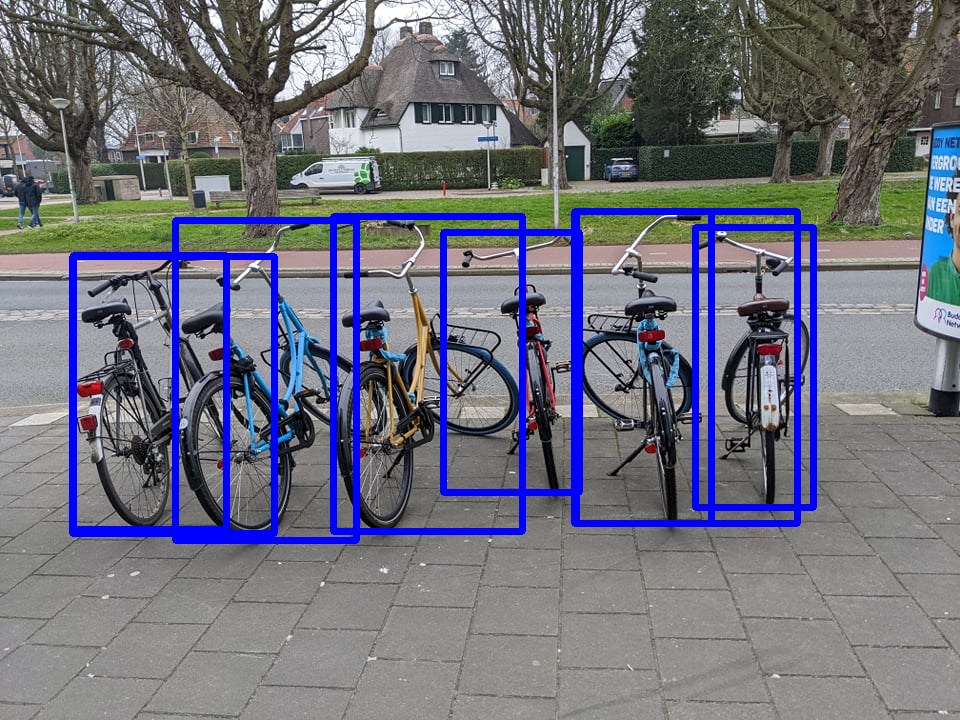

In [12]:
#  Call the draw_rect function, which draws rectangles around the objects that
#  it detect with the label 'bicycle' and writes it to the file 'test.png'
draw_rect(my_image, API_URL, API_TOKEN, label='bicycle')
# Show the image file 'test.png'
Image(filename='test.png')

## Single Code Block


In [ ]:
!git clone https://github.com/ml4design/image-processing-tutorial

"""
# Import python packages.
"""
import json
import requests
import cv2

API_URL = "https://api-inference.huggingface.co/models/google/vit-base-patch16-224"
API_TOKEN = userdata.get('API_TOKEN')


# Below is a reusable function for interacting with the Hugging Face API.
def query(file_path, api_url, api_token):
    """
    Ask the Hugging Face API to run the model and return the result.

    Attributes
    ----------
    file_path : str
        The path to the image file that we want to send to the Hugging Face API.
    api_url : str
        The API URL that points to a specific machine learning model.
    api_token : str
        The API token for authentication.
    """
    # Construct the header of the HTTP request that includes the API token.
    headers = {"Authorization": f"Bearer " + api_token}
    # Read the input data.
    with open(file_path, "rb") as f:
        data = f.read()
    # Make a POST request to the API with the token and input data.
    response = requests.request("POST", api_url, headers=headers, data=data)
    # Return the output from the API
    return json.loads(response.content.decode("utf-8"))

# Below is another resuable function for counting the number of objects in an image
def count_objects(file_path, api_url, api_token, label):
    """
    Ask the Hugging Face API to run the model and count the number of objects.

    Usage example:
        data = count_objects("data/000000039769.jpeg", API_URL, API_TOKEN, "bicycle")

    Attributes
    ----------
    file_path : str
        The path to the image file that we want to send to the Hugging Face API.
    api_url : str
        The API URL that points to a specific machine learning model.
    api_token : str
        The API token for authentication.
    label : str
        The label of the object that we want to count (e.g., "bicycle").
    """
    data = query(file_path, API_URL, API_TOKEN)
    count = 0
    for d in data:
        if d["label"] == label:
            count += 1
    return count

# Here is a function that draw a rectange around objects with the given label
def draw_rect(file_path, api_url, api_token, label, image_name='./test.png'):
  img = cv2.imread(file_path)
  data = query(file_path, api_url, api_token)

  for d in data:
    if d["label"] == label:
      cv2.rectangle(img, (d['box']['xmin'], d['box']['ymin']),
                    (d['box']['xmax'], d['box']['ymax']), 255, 5)

  cv2.imwrite(image_name, img)

# first say which image you want to use
my_image = "image-processing-tutorial/data/000000039769.jpeg"
# then call the query function and store the results in memory as the "data" variable
data = query(my_image, API_URL, API_TOKEN)

# use this line of code to print the output in a more organized and readable way.
print(json.dumps(data, indent=2))

fatal: destination path 'image-processing-tutorial' already exists and is not an empty directory.
[
  {
    "label": "Egyptian cat",
    "score": 0.9374415874481201
  },
  {
    "label": "tabby, tabby cat",
    "score": 0.03844254091382027
  },
  {
    "label": "tiger cat",
    "score": 0.01441141776740551
  },
  {
    "label": "lynx, catamount",
    "score": 0.003274336690083146
  },
  {
    "label": "Siamese cat, Siamese",
    "score": 0.0006795947556383908
  }
]


## FAQs and Troubleshooting



1.  I got an error from the query function that shows this:  
```{
  "error": "Model google/vit-base-patch16-224 is currently loading",  
  "estimated_time": 20.0
}```
  *  This is because Huggingface needs to load the model into memory, just wait 20 seconds and run the qeury again.
2. I got the error:  
`FileNotFoundError: [Errno 2] No such file or directory: '/content/image-processing-tutorial/data/000000039769.jpeg'`.
  *  Make sure that the files exists in the current workspace by inspecting the Files section. Also make
sure to run the first few cells of code so that the workspace downloads the files for the tutorial.
3. I got the error:  
`
SecretNotFoundError: Secret API_TOKEN does not exist.
`
  *  Add the secret `API_TOKEN` to your notebook by selecting the key symbol and pressing the `Add new secret` option. In the name should be `API_TOKEN` and the value should be the API key you generated with your hugging face account.
  * Another option is to copy paste your API key directly into your code. For example: `API_TOKEN = "[YOUR API KEY HERE]"`
4. Gemini is not working for me:
  * If you just created your google account and/or not verified your age, then you will not be able to use Gemini.